In [9]:
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
load_dotenv()

model = init_chat_model("google_genai:gemini-2.5-flash-lite")

In [10]:
# 상태
from typing import TypedDict, Literal

class State(TypedDict):
    value: int
    decision: Literal["even", "odd"]

In [11]:
from langchain.messages import SystemMessage, HumanMessage

def check_condition_node(state: State):
    print("check_condition_node 실행")
    print(f"value = {state["value"]}")

    system_prompt = (
        "당신은 업무흐름 라우팅을 담당하는 어시스턴트입니다.\n"
        "숫자가 짝수면 'even', 홀수면 'odd'만 정확히 출력하세요.\n"
        "추가 설명이나 다른 텍스트는 절대 출력하지 마세요."
    )
    
    user_prompt = f"숫자 {state['value']}는 짝수인가요, 홀수인가요?"

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt)
    ]

    response = model.invoke(messages)
    decision = response.content.strip().lower()
    
    print(f"판단: {decision}")

    print("-" * 20)

    return {"decision": decision}

In [12]:
def even_node(state: State):
    print("even_node 실행(짝수)")
    print(f"value = {state["value"]}")
    return state

def odd_node(state: State):
    print("odd_node 실행(홀수)")
    print(f"value = {state["value"]}")
    return state

In [13]:
def router(state: State) -> Literal["even", "odd"]:
    print("router 실행")
    print(f"State에 저장된 decision: {state['decision']}")

    if state["decision"] == "even":
        print("짝수 Node로 이동")
        return "even"
    else:
        print("홀수 Node로 이동")
        return "odd"

In [14]:
from langgraph.graph import StateGraph, START, END

graph_builder = StateGraph(State)

graph_builder.add_node(check_condition_node)
graph_builder.add_node(even_node)
graph_builder.add_node(odd_node)
# graph_builder.add_node("check_condition_node", check_condition_node)
# graph_builder.add_node("even_node", even_node)
# graph_builder.add_node("odd_node", odd_node)

graph_builder.add_edge(START, "check_condition_node")
# 조건부 엣지
graph_builder.add_conditional_edges(
    "check_condition_node",
    router,
    {
        "even": "even_node",
        "odd": "odd_node"
    }
)

graph_builder.add_edge("even_node", END)
graph_builder.add_edge("odd_node", END)

graph = graph_builder.compile()

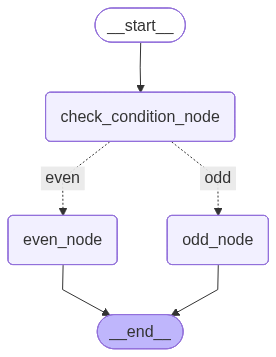

In [15]:
graph

In [16]:
graph.invoke({"value": 2})

check_condition_node 실행
value = 2
판단: even
--------------------
router 실행
State에 저장된 decision: even
짝수 Node로 이동
even_node 실행(짝수)
value = 2


{'value': 2, 'decision': 'even'}

In [17]:
graph.invoke({"value": 3})

check_condition_node 실행
value = 3
판단: odd
--------------------
router 실행
State에 저장된 decision: odd
홀수 Node로 이동
odd_node 실행(홀수)
value = 3


{'value': 3, 'decision': 'odd'}